C:\Users\USER\AppData\Local\Temp\ipykernel_8176\425472219.py:9: DtypeWarning: Columns (1,4,5,6,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('metadata.csv')


   cord_uid                                       sha source_x  \
0  ug7v899j  d1aafb70c066a2068b02786f8929fd9c900897fb      PMC   
1  02tnwd4m  6b0567729c2143a66d737eb0a2f63f2dce2e5a7d      PMC   
2  ejv2xln0  06ced00a5fc04215949aa72528f2eeaae1d58927      PMC   
3  2b73a28n  348055649b6b8cf2b9a376498df9bf41f7123605      PMC   
4  9785vg6d  5f48792a5fa08bed9f56016f4981ae2ca6031b32      PMC   

                                               title                    doi  \
0  Clinical features of culture-proven Mycoplasma...  10.1186/1471-2334-1-6   
1  Nitric oxide: a pro-inflammatory mediator in l...           10.1186/rr14   
2    Surfactant protein-D and pulmonary host defense           10.1186/rr19   
3               Role of endothelin-1 in lung disease           10.1186/rr44   
4  Gene expression in epithelial cells in respons...           10.1186/rr61   

      pmcid pubmed_id license  \
0  PMC35282  11472636   no-cc   
1  PMC59543  11667967   no-cc   
2  PMC59549  11667972   no-cc

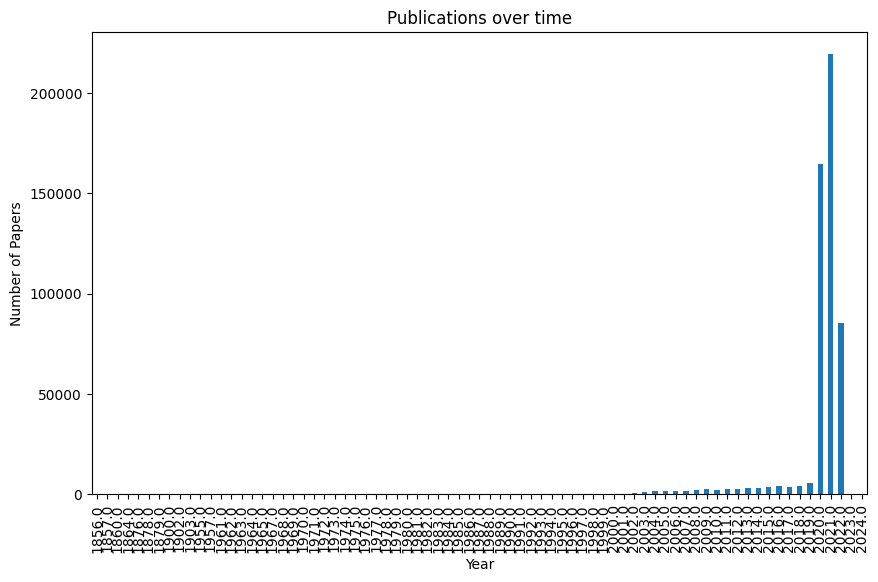

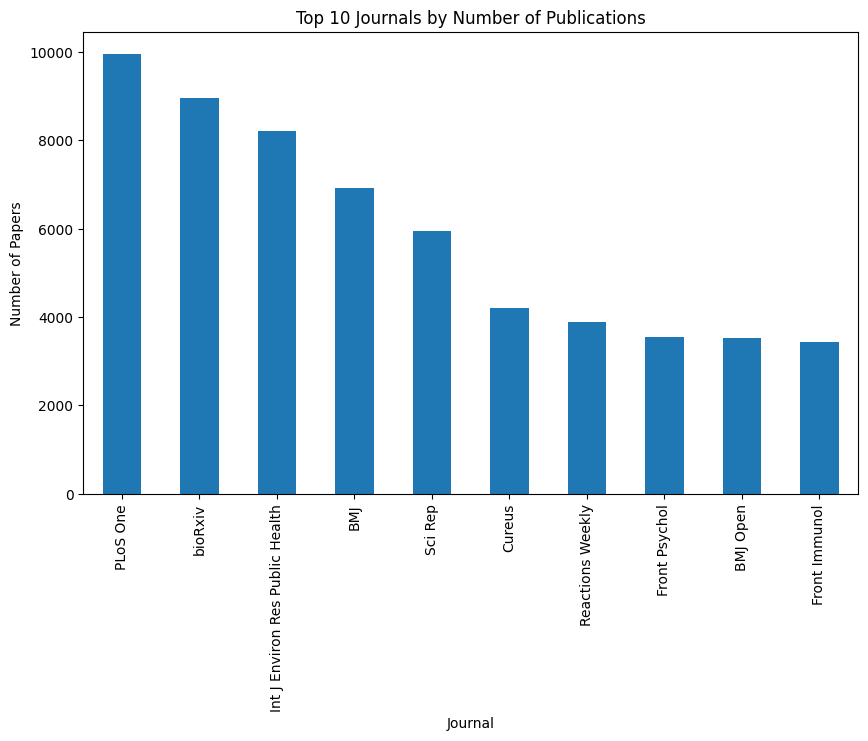

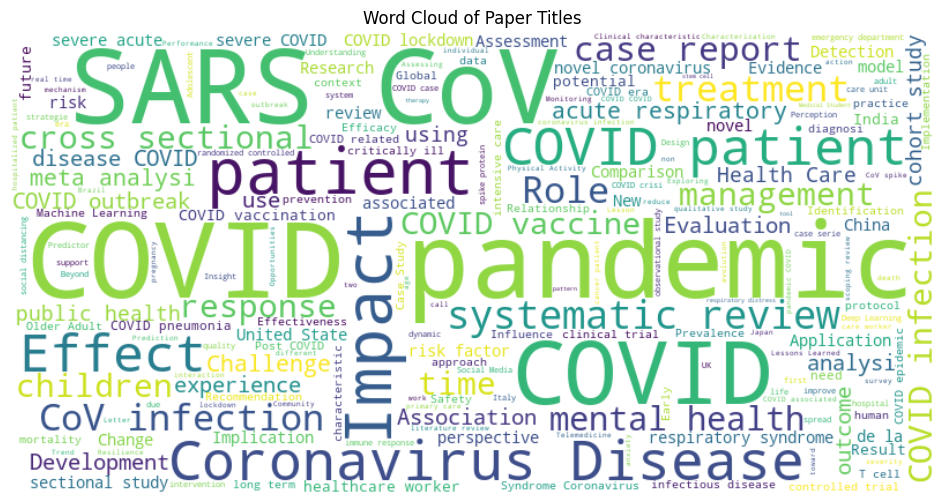

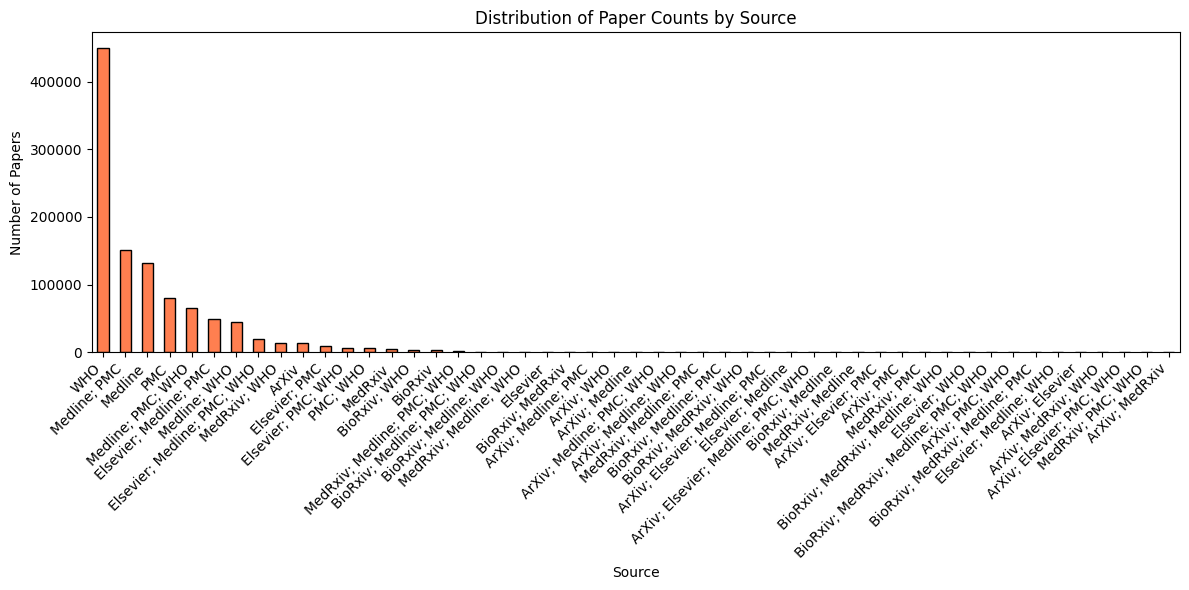

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import streamlit as st

#Data loading and basic exploration
df = pd.read_csv('metadata.csv')
print(df.head())
print(df.info())
print(df.shape)
print(df.isnull().sum() )
#df.describe()

#Data cleaining
df_clean = df.copy()

df_clean['publish_time'] = pd.to_datetime(df['publish_time'],errors='coerce')
df_clean['publish_year'] = df_clean['publish_time'].dt.year

df_clean['abstract_word_count'] = df_clean['abstract'].fillna('').apply(lambda x: len(x.split())) #

print(df_clean[['abstract', 'abstract_word_count']].head())


#data analysis and visualization
count_papers_by_year = df_clean['publish_year'].value_counts().sort_index() 
print(count_papers_by_year)
top_journals = df_clean['journal'].value_counts().head(10)

all_titles = ' '.join(df_clean['title'].dropna()).lower().split()
word_counts = Counter(all_titles)

# Get the 10 most common words
most_common_words = word_counts.most_common(10)
for word, count in most_common_words:
    print(f"{word}: {count}")


# Visualization
plt.figure(figsize=(10, 6))
count_papers_by_year.plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.title('Publications over time')
plt.show()


#Bar chat for top journals
plt.figure(figsize=(10, 6))
top_journals.plot(kind='bar')
plt.xlabel('Journal')
plt.ylabel('Number of Papers')
plt.title('Top 10 Journals by Number of Publications')
plt.show()

title_text = ' '.join(df_clean['title'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(title_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Paper Titles')
plt.show()

plt.figure(figsize=(12, 6))
source_counts = df_clean['source_x'].value_counts()
source_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Source')
plt.ylabel('Number of Papers')
plt.title('Distribution of Paper Counts by Source')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

